# Logistic Regression versus Bayes Classifier

 Question 7 Discriminative vs Generative Models

In [1]:
#Importing the library for this question
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss
from scipy.stats import multivariate_normal
from matplotlib import pyplot as plt


7.1 Load the breast cancer dataset via load breast LogisticRegression from sklearn.linear cancer in sklearn.datasets, import model, and copy the code from Activity 3.3. for the Bayes classifier (BC). For the Bayes classifier consider the Naive Bayes variant (without shared covariance) as well as the variants with full covariance (shared and not shared). Perform a training/test split (with train size equal to 0.8) and report which of the models performs best in terms of train and test performance.

In [2]:
#Bayes Classifier from activity

class BayesianClassifier:
    #Initialize the init
    def __init__(self, shared_cov=True, cond_ind=True):
        self.shared_cov=shared_cov
        self.cond_ind=cond_ind
    #Making the fit function for bayesian classifier
    def fit(self, x, y):
        self.classes_, class_counts = np.unique(y, return_counts=True)
        #Initializing the shape of the dataset
        self.n_ , self.p_ = x.shape
        #Initializing the k
        self.k_ = len(self.classes_)
        #Initializing the array for the mean and covariance
        self.cond_means_ = np.zeros(shape=(self.k_, self.p_))
        self.cond_covs_ = np.zeros(shape=(self.k_, self.p_, self.p_))
        #Initializing the class prior
        self.class_priors_ = class_counts/len(y)
        #For loop to count the conditional means and covariance for each class
        for c in range(self.k_):
            c_rows = y==c
            self.cond_means_[c, :] = x[c_rows].mean(axis=0)
            if self.cond_ind:
                np.fill_diagonal(self.cond_covs_[c, :, :], x[c_rows].var(axis=0))
            else:
                self.cond_covs_[c, :, :] = np.cov(x[c_rows].T, bias=True)
        #Function to count if it's using shared covariance
        if self.shared_cov:
            shared_cov = np.moveaxis(self.cond_covs_, 0, -1).dot(self.class_priors_)
            self.cond_covs_[:] = shared_cov

        return self
    #To count the probability which class the datapoint belong to
    def predict_proba(self, x):
        m, _ = x.shape
        cond_probs = np.zeros(shape=(m, self.k_))
        for c in range(self.k_):
            # find p(x | c_k)
            # singular covariance matrices could happen (e.g., through inaccurate estimation)
            cond_probs[:, c] = multivariate_normal.pdf(x, 
                                                       self.cond_means_[c],
                                                       self.cond_covs_[c],
                                                       allow_singular=True)
        # find marginal probabilities p(x) by summing all the conditionals weighted by the priors
        marginal_probs = cond_probs.dot(self.class_priors_)

        # find probability vector (p(c1 | x), ..., p(ck | x)) via p(ci | x)=p(x | ci) / p(x)
        # however, p(x) might have been rounded to 0
        # thus, compute via case distinction
        probs = np.divide((cond_probs*self.class_priors_).T,
                          marginal_probs,
                          where=marginal_probs>0, out=np.zeros(shape=(self.k_, m))).T
        return probs
    #To classify the dataset
    def predict(self, x):
        return np.argmax(self.predict_proba(x), axis=1)
    #To count the confidence level of the probability to put the datapoint in the class
    def decision_function(self, x):
        probs = self.predict_proba(x)
        if self.k_ == 2:
            return np.log(probs[:, 1]/probs[:, 0])
        else:
            res = np.zeros(len(x), self.k_)
            for c in range(self.k_):
                res[:, c]=np.log(probs[:, c]/(1-probs[:, c]))
            return res
    #To generate new datapoints based on the learned bayes classifier model from the dataset previously     
    def generate(self, n, c, random_state=None):
        return multivariate_normal.rvs(self.cond_means_[c], self.cond_covs_[c], size=n, random_state=random_state)

In [3]:
#Load the dataset and split the dataset
breast_cancer = load_breast_cancer()
cancer_x_train, cancer_x_test, cancer_y_train, cancer_y_test = train_test_split(breast_cancer.data, breast_cancer.target, test_size=0.8, random_state=42)

#The solver is chosen to be newton-cholesky because when I tried lbfgs *the default* and newton-cg a warning appear saying that it doesn't converge.
#When I choose newton-cholesky it converges that's why I choose it
#Create an object containing each function
lr = LogisticRegression(solver='newton-cholesky')
nb = BayesianClassifier(shared_cov=False, cond_ind=True)
bc_shared = BayesianClassifier(shared_cov=True, cond_ind=False)
bc = BayesianClassifier(shared_cov=False, cond_ind=False)

#Fitting the model to the cancer dataset
lr_model_7 = lr.fit(cancer_x_train, cancer_y_train)
nb_model_7 = nb.fit(cancer_x_train, cancer_y_train)
bc_shared_model_7 = bc_shared.fit(cancer_x_train, cancer_y_train)
bc_model_7 = bc.fit(cancer_x_train, cancer_y_train)


In [4]:
#Counting and printing the train error
#Note that logistic regression model that is used here is the default one from sklearn with l2 penaly, lbfgs solver, and 100 max iter

print('Logistic Regression:', zero_one_loss(cancer_y_train, lr_model_7.predict(cancer_x_train)))
print('Naive Bayes without shared covariance:', zero_one_loss(cancer_y_train, nb_model_7.predict(cancer_x_train)))
print('Bayes Classifier with shared covariance:', zero_one_loss(cancer_y_train, bc_shared_model_7.predict(cancer_x_train)))
print('Bayes Classifier without shared covariance:', zero_one_loss(cancer_y_train, bc_model_7.predict(cancer_x_train)))


Logistic Regression: 0.07079646017699115
Naive Bayes without shared covariance: 0.08849557522123896
Bayes Classifier with shared covariance: 0.053097345132743334
Bayes Classifier without shared covariance: 0.06194690265486724


Therefore the best model is Bayes Classifier with/without shared covariance for the train performance

In [5]:
#Counting and printing the test error
#Note that logistic regression model that is used here is the default one from sklearn with l2 penaly, lbfgs solver, and 100 max iter

print('Logistic Regression:', zero_one_loss(cancer_y_test, lr_model_7.predict(cancer_x_test)))
print('Naive Bayes without shared covariance:', zero_one_loss(cancer_y_test, nb_model_7.predict(cancer_x_test)))
print('Bayes Classifier with shared covariance:', zero_one_loss(cancer_y_test, bc_shared_model_7.predict(cancer_x_test)))
print('Bayes Classifier without shared covariance:', zero_one_loss(cancer_y_test, bc_shared_model_7.predict(cancer_x_test)))


Logistic Regression: 0.030701754385964897
Naive Bayes without shared covariance: 0.08552631578947367
Bayes Classifier with shared covariance: 0.04166666666666663
Bayes Classifier without shared covariance: 0.04166666666666663


Therefore the best model is logistic regression for the test performance

## Question 7.2

Implement an experiment where you test theperformance for increasing training sizes of N=5,10,...,500. For each N sample 10 training sets of the corresponding size, fit all models,and record training and test errors.

In [6]:
# Initialize a list for the N then append it from 5 to 500
n_size = []

for u in range(5, 501, 5):
    n_size.append(u)

#Initialize the array for all model train and test result
lr_error_train = np.zeros(shape=(len(n_size),10))
nbwsc_error_train = np.zeros(shape=(len(n_size),10))
bcsc_error_train = np.zeros(shape=(len(n_size),10))
bcwsc_error_train = np.zeros(shape=(len(n_size),10))
lr_error_test = np.zeros(shape=(len(n_size),10))
nbwsc_error_test = np.zeros(shape=(len(n_size),10))
bcsc_error_test = np.zeros(shape=(len(n_size),10))
bcwsc_error_test = np.zeros(shape=(len(n_size),10))

#For loop to test the performance for increasing training size and sampling it 10 times
#For the 10 times resampling
for j in range(10):
    #For the increasing training size
    for i in range(len(n_size)):
        #Splitting the cancer data, random state is j so that it will be shuffle the resampling
        cancer_x_train, cancer_x_test, cancer_y_train, cancer_y_test = train_test_split(breast_cancer.data, breast_cancer.target, train_size= n_size[i],
                                                                                        random_state=j, shuffle=True)
        #Fit the logistic regression model and count the zero one loss error for train and test
        lr_model_7_2 = lr.fit(cancer_x_train, cancer_y_train)
        lr_error_train[i,j] = zero_one_loss(cancer_y_train, lr_model_7_2.predict(cancer_x_train))
        lr_error_test[i,j] = zero_one_loss(cancer_y_test, lr_model_7_2.predict(cancer_x_test))
        #Fit the naive bayes model and count the zero one loss error for train and test
        nb_model_7_2 = nb.fit(cancer_x_train, cancer_y_train)
        nbwsc_error_train[i,j] = zero_one_loss(cancer_y_train, nb_model_7_2.predict(cancer_x_train))
        nbwsc_error_test[i,j] = zero_one_loss(cancer_y_test, nb_model_7_2.predict(cancer_x_test))
        #Fit the bayes classifier with shared covariance model and count the zero one loss error for train and test
        bc_shared_model_7_2 = bc_shared.fit(cancer_x_train, cancer_y_train)
        bcsc_error_train[i,j] = zero_one_loss(cancer_y_train, bc_shared_model_7_2.predict(cancer_x_train))
        bcsc_error_test[i,j] = zero_one_loss(cancer_y_test, bc_shared_model_7_2.predict(cancer_x_test))
        #Fit the bayes classifier without shared covariance model and count the zero one loss error for train and test
        bc_model_7_2 = bc.fit(cancer_x_train, cancer_y_train)
        bcwsc_error_test[i,j] = zero_one_loss(cancer_y_test, bc_model_7_2.predict(cancer_x_test))
        bcwsc_error_train[i,j] = zero_one_loss(cancer_y_train, bc_model_7_2.predict(cancer_x_train))




## Question 7.3

Create suitable plots that compare the mean train and test performances of all models as a function of training size. There is no need to include error bars if that makes the plot too hard to read.

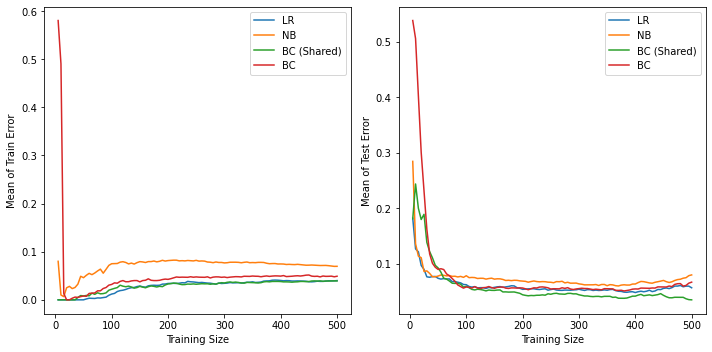

In [10]:
#Plotting the mean of train and test error for all model
_, axs = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)

#Plot the train error
#Plot the train LR error
axs[0].plot(n_size, lr_error_train.mean(axis=1), label = 'LR')
#Plot the train NB error
axs[0].plot(n_size, nbwsc_error_train.mean(axis=1), label = 'NB')
#Plot the train BC (shared) error
axs[0].plot(n_size, bcsc_error_train.mean(axis=1), label = 'BC (Shared)')
#Plot the train BC error
axs[0].plot(n_size, bcwsc_error_train.mean(axis=1), label = 'BC')
#Setting the x and y label
axs[0].set_xlabel('Training Size')
axs[0].set_ylabel('Mean of Train Error')
axs[0].legend()
#Plot the test error
#Plot the test LR error
axs[1].plot(n_size, lr_error_test.mean(axis=1), label = 'LR')
#Plot the train NB error
axs[1].plot(n_size, nbwsc_error_test.mean(axis=1), label = 'NB')
#Plot the train BC (shared) error
axs[1].plot(n_size, bcsc_error_test.mean(axis=1), label = 'BC (Shared)')
#Plot the train BC error
axs[1].plot(n_size, bcwsc_error_test.mean(axis=1), label = 'BC')
#Setting the x and y label
axs[1].set_xlabel('Training Size')
axs[1].set_ylabel('Mean of Test Error')
axs[1].legend()
plt.show()

## 7.4 Formulate answers to the following questions

a What happens to each classifiers train and test performance when the number of training data points is increased?

b Which classifier is best suited when the training set is small, and which is best suited when the training set is big?
 
c Justify your observations by providing some speculations and possible reasons.



a. By increasing the training size, all classifiers train error became higher while their test error became lower.

b. Classifier that's best suited for low training dataset from the graph is Logistic Regression while the classifier that's best suited for high training set is either logistic regression or bayes classifier with shared covariance

c. Logistic regression being the best in small training dataset setting correspond with the theory because it is robust with small dataset provided there's a linear correlation with the data and the target. It also has fewer parameter to model so it work better with lower datacount.

For the big training dataset, it's either logistic regression or bayes classifier with shared covariance. Logistic regression does still work well although the model is not complex and has low parameter provided there's a linear relationship between the data that the cancer dataset might have. Also more data means that the weight for logistic regression can be more accurate making the model more robust. For the Bayes Classifier with shared covariance, this model simplify the parameters by assuming that all datapoint share a covariance. The fact that bayes classifier with shared covariance also has the lowest error rate means that the shared covariance model of this model capture the relation between the dataset well enough therefore it has the lowest error rate. While assuming that the dataset doesn't share a covariance might work better generally, the fact after testing still shows that bayes classifier with shared covariance still have the lowest error rate shows that the cancer dataset works better when you assume that the parameter share a covariance